In [1]:
import pandas as pd

In [5]:
# heart_df = pd.read_csv('./data/heart.csv')
heart_df = pd.read_csv('./data/heart_2020_cleaned.csv')
heart_df['HeartDisease'] = heart_df['HeartDisease'].map({'No':0,'Yes':1})
heart_df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,0,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,0,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,0,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,0,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,1,27.41,Yes,No,No,7,0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6,Yes,No,No
319791,0,29.84,Yes,No,No,0,0,No,Male,35-39,Hispanic,No,Yes,Very good,5,Yes,No,No
319792,0,24.24,No,No,No,0,0,No,Female,45-49,Hispanic,No,Yes,Good,6,No,No,No
319793,0,32.81,No,No,No,0,0,No,Female,25-29,Hispanic,No,No,Good,12,No,No,No


Voting classifier with hard voting

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# ---------------------------
# 1. Load data
# ---------------------------
df = pd.read_csv("./data/heart_2020_cleaned.csv")
df['HeartDisease'] = df['HeartDisease'].map({'No':0, 'Yes':1})

X = df.drop("HeartDisease", axis=1)  
# ---------------------------
# 2. Column types
# ---------------------------
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

# ---------------------------
# 3. Preprocessing
# ---------------------------
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

# ---------------------------
# 4. Train-test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ---------------------------
# 5. Handle imbalance with SMOTE
# ---------------------------
smote = SMOTE(random_state=42)

# ---------------------------
# 6. Define base models with best parameters observed
# ---------------------------
rf = RandomForestClassifier(
    n_estimators=250,
    max_depth=12,
    random_state=42,
    class_weight='balanced'
)

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5
)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=(sum(y_train==0)/sum(y_train==1)),
    random_state=42
)

lr = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    solver='liblinear'
)

# ---------------------------
# 7. Voting Classifier
# ---------------------------
voting_clf = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('xgb', xgb), ('lr', lr)],
    voting='hard',
    n_jobs=-1,
    weights=[1,2,2,1]  # give more weight to boosting models
)

# ---------------------------
# 8. Full pipeline
# ---------------------------
pipeline = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', smote),
    ('voting', voting_clf)
])

# ---------------------------
# 9. Train
# ---------------------------
pipeline.fit(X_train, y_train)
 
# ---------------------------                      nb hg
# 10. Predict probabilities and classes
# ---------------------------
y_pred = pipeline.predict(X_test)  # risk score (0-1)

# ---------------------------
# 11. Evaluate
# ---------------------------
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Voting Classifier with soft voting (SMOTE)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# ---------------------------
# 1. Load data
# ---------------------------
df = pd.read_csv("./data/heart_2020_cleaned.csv")
#df['HeartDisease'] = df['HeartDisease'].map({'No':0, 'Yes':1})

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# ---------------------------
# 2. Column types
# ---------------------------
numeric_cols = X.select_dtypes(include='number').columns
categorical_cols  = X.select_dtypes(exclude='number').columns
# categorical_cols = X.select_dtypes(include=['object']).columns
# numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

# ---------------------------
# 3. Preprocessing
# ---------------------------
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

# ---------------------------
# 4. Train-test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ---------------------------
# 5. Handle imbalance with SMOTE
# ---------------------------
smote = SMOTE(random_state=42)

# ---------------------------
# 6. Define base models with best parameters observed
# ---------------------------
rf = RandomForestClassifier(
    n_estimators=250,
    max_depth=12,
    random_state=42,
    class_weight='balanced'
)

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5
)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=(sum(y_train=='No')/sum(y_train=='Yes')),
    random_state=42
)

lr = LogisticRegression(
    max_iter=1000,#set back to 5000 later
    class_weight='balanced',
    solver='liblinear'
)

# ---------------------------
# 7. Voting Classifier
# ---------------------------
voting_clf = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('xgb', xgb), ('lr', lr)],
    voting='soft',
    n_jobs=-1,
    weights=[1,2,2,1]  # give more weight to boosting models
)

# ---------------------------
# 8. Full pipeline
# ---------------------------
pipeline = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', smote),
    ('voting', voting_clf)
])

# ---------------------------
# 9. Train
# ---------------------------
pipeline.fit(X_train, y_train)

# ---------------------------
# 10. Predict probabilities and classes
# ---------------------------
y_proba = pipeline.predict_proba(X_test)[:,1]  # risk score (0-1)

# Tunable threshold to balance recall vs precision
threshold = 0.3
# y_pred = (y_proba >= threshold).astype(int)

# # ---------------------------
# # 11. Evaluate
# # ---------------------------
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# print("\nClassification Report:\n", classification_report(y_test, y_pred))

# # ---------------------------
# # 12. Risk categories for app
# # ---------------------------
# def get_risk_category(prob):
#     if prob < 0.2:
#         return 'Low'
#     elif prob < 0.5:
#         return 'Moderate'
#     else:
#         return 'High'

# risk_category = [get_risk_category(p) for p in y_proba]

# # ---------------------------
# # 13. Create final output DataFrame
# # ---------------------------
# df_result = X_test.copy()
# df_result['RiskScore'] = y_proba
# df_result['RiskCategory'] = risk_category
# df_result['PredictedLabel'] = y_pred
# df_result['TrueLabel'] = y_test.values

# df_result.head()

TypeError: Labels in y_true and y_pred should be of the same type. Got y_true=['No' 'Yes'] and y_pred=[0 1]. Make sure that the predictions provided by the classifier coincides with the true labels.

In [21]:
y_pred

array([1, 1, 0, ..., 1, 1, 1], shape=(63959,))

In [22]:
import pickle
pickle.dump(pipeline,
            open(file='./models/trained_pipe_soft_voting_rf_gb_xgb_lr2.sav',
                 mode='wb'))

In [ ]:
import pickle
pipeline = pickle.load(open('./models/trained_pipe_soft_voting_rf_gb_xgb_lr.sav', 'rb'))

In [23]:
def compute_shap_plot_voting(pipeline, user, user2=None, background_data=None):
    """
    Compute SHAP plot for VotingClassifier with optional What-If comparison.
    
    Parameters:
    - pipeline: Trained pipeline with VotingClassifier
    - user: Original user DataFrame
    - user2: Modified user DataFrame (optional, for What-If scenario)
    - background_data: Sample of training data for KernelExplainer (e.g., 100 samples)
    """

    # Preprocess user data
    X_user_preprocessed = pipeline.named_steps["preprocess"].transform(user)
    
    # Get encoded feature names
    encoded_feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
    
    # Create prediction function for SHAP
    def predict_proba_fn(X):
        """Returns probability of positive class"""
        return pipeline.named_steps["voting"].predict_proba(X)[:, 1]
    
    # Initialize KernelExplainer
    if background_data is None:
        # Use a small summary (e.g., kmeans with k=10 or just the user itself)
        background = X_user_preprocessed  
        print("Warning: No background data provided. Using user data as background (not ideal).")
    else:
        # Preprocess background data
        background = pipeline.named_steps["preprocess"].transform(background_data)
    
    explainer = shap.KernelExplainer(predict_proba_fn, background)
    
    # Compute SHAP values (this will be SLOW without proper background data)
    shap_values = explainer.shap_values(X_user_preprocessed, nsamples=100)  # adjust nsamples for speed/accuracy tradeoff
    
    # [REST OF YOUR CODE REMAINS THE SAME - aggregation, plotting, etc.]
    # Aggregate SHAP values by original feature
    original_importances = {}
    
    for i, encoded_name in enumerate(encoded_feature_names):
        if '__' in encoded_name:
            original_feature = encoded_name.split('__')[1].rsplit('_', 1)[0]
        else:
            original_feature = encoded_name.split('_')[0]
        
        shap_value = shap_values[0][i]  # Note: different indexing for KernelExplainer
        
        if original_feature in original_importances:
            original_importances[original_feature] += shap_value
        else:
            original_importances[original_feature] = shap_value
    # Convert to DataFrame
    importance_df = pd.DataFrame({
        'feature': list(original_importances.keys()),
        'shap_value': list(original_importances.values())
    })

    # NEW: Add user values to feature labels
    def format_feature_label(feature_name):
        """Create label showing feature name and user's value"""
        if feature_name not in user.columns:
            return feature_name
        
        value = user[feature_name].iloc[0]
        
        # Format based on value type
        if isinstance(value, (int, float)):
            if value in [0, 1]:  # Binary encoded as 0/1
                return f"{feature_name}: {'Yes' if round(value) == 1 else 'No'}"
            else:
                return f"{feature_name}: {value}"
        else:  # Categorical
            return f"{feature_name}: {value}"
    
    importance_df['feature_label'] = importance_df['feature'].apply(format_feature_label)

    # If user2 is provided, compute SHAP values for modified data
    whatif_importances = None
    changed_features = []
    if user2 is not None:
        # Find which features changed
        for col in user.columns:
            if user[col].iloc[0] != user2[col].iloc[0]:
                changed_features.append(col)
        
        # Compute SHAP values for user2
        X_user2_preprocessed = model.named_steps["prep"].transform(user2)
        shap_values2 = explainer(X_user2_preprocessed)
        
        # Aggregate SHAP values for user2
        whatif_importances = {}
        for i, encoded_name in enumerate(encoded_feature_names):
            if '__' in encoded_name:
                original_feature = encoded_name.split('__')[1].rsplit('_', 1)[0]
            else:
                original_feature = encoded_name.split('_')[0]
            
            shap_value = shap_values2.values[0, i]
            
            if original_feature in whatif_importances:
                whatif_importances[original_feature] += shap_value
            else:
                whatif_importances[original_feature] = shap_value

    # Define modifiability levels
    HIGHLY_MODIFIABLE = {
        "Smoking",
        "AlcoholDrinking",
        "PhysicalActivity",
        "BMI",
        "SleepTime",
    }

    MODERATELY_MODIFIABLE = {
        "PhysicalHealth",
        "MentalHealth",
        "GenHealth",
        "DiffWalking",
    }

    # Classify features
    def get_modifiability(feature):
        if feature in HIGHLY_MODIFIABLE:
            return 'highly'
        elif feature in MODERATELY_MODIFIABLE:
            return 'moderately'
        else:
            return 'non'

    importance_df['modifiability'] = importance_df['feature'].apply(get_modifiability)

    # Sort by absolute value
    importance_df['abs_shap'] = importance_df['shap_value'].abs()
    importance_df = importance_df.sort_values('abs_shap', ascending=True)

    # Assign colors based on direction and modifiability
    def get_color(row):
        if row['shap_value'] < 0:  # Decreases risk (green)
            if row['modifiability'] == 'highly':
                return "#0c632c"  # Dark green
            elif row['modifiability'] == 'moderately':
                return "#569C70"  # Medium green
            else:
                return "#94d1ab"  # Light green
        else:  # Increases risk (rose)
            if row['modifiability'] == 'highly':
                return '#f43f5e'  # Dark rose
            elif row['modifiability'] == 'moderately':
                return "#f78495"  # Medium rose
            else:
                return "#fcbbc3"  # Light rose

    importance_df['color'] = importance_df.apply(get_color, axis=1)

    # Create the plot
    fig, ax = plt.subplots(figsize=(7, 4))

    bars = ax.barh(importance_df['feature'], importance_df['shap_value'], 
                color=importance_df['color'], alpha=0.9)

    # Add value labels on bars with modifiability markers
    for i, (bar, value, modifiability) in enumerate(zip(bars, importance_df['shap_value'], 
                                                        importance_df['modifiability'])):
        label_x = value + (0.002 if value > 0 else -0.002)
        alignment = 'left' if value > 0 else 'right'
                                            
        ax.text(label_x, bar.get_y() + bar.get_height()/2, 
                f'{value:.2f}', 
                va='center', ha=alignment, fontsize=8)

    # Plot What-If scenario as blue dots if available
    if whatif_importances is not None and changed_features:
        # Add What-If values as blue dots for changed features
        for idx, row in importance_df.iterrows():
            feature = row['feature']
            if feature in changed_features and feature in whatif_importances:
                whatif_value = whatif_importances[feature]
                # Use the enumerated position in the sorted dataframe
                y_position = list(importance_df['feature']).index(feature)
                
                # Plot blue dot
                ax.plot(whatif_value, y_position, 'o', color='#0055A4', 
                       markersize=7, zorder=5)
                
                # Add label for What-If value
                label_x = whatif_value#whatif_value + (0.02 if whatif_value > 0 else -0.02)
                alignment = 'left' if whatif_value > 0 else 'right'
                ax.text(label_x, y_position, f'  {whatif_value:.2f}  ', 
                       va='center', ha=alignment, fontsize=8, 
                       color='#0055A4')

    # Add vertical line at zero
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)

    # Labels and title
    ax.set_xlabel('SHAP Value (Impact on Risk)', fontsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=8)

    # Add legend
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    legend_elements = [
        Patch(facecolor='#f43f5e', label='Risk ↑ (Highly Modifiable)', alpha=0.9),
        Patch(facecolor="#f78495", label='Risk ↑ (Moderately Modifiable)', alpha=0.9),
        Patch(facecolor="#fcbbc3", label='Risk ↑ (Non-modifiable)', alpha=0.9),
        Patch(facecolor="#0c632c", label='Risk ↓ (Highly Modifiable)', alpha=0.9),
        Patch(facecolor="#569C70", label='Risk ↓ (Moderately Modifiable)', alpha=0.9),
        Patch(facecolor="#94d1ab", label='Risk ↓ (Non-modifiable)', alpha=0.9),
    ]
    
    # Add What-If legend item if applicable
    if whatif_importances is not None and changed_features:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#0055A4', 
                   markersize=8, label='What-If Scenario', markeredgecolor='white')
        )
    
    ax.legend(handles=legend_elements, loc='best', fontsize=8, framealpha=0)

    # Grid
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    return fig, importance_df

In [33]:
user_df


,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
133926,49.39,Yes,No,No,25,2,Yes,Female,45-49,White,No,Yes,Fair,6,Yes,No,No


In [35]:
user_df = pd.DataFrame([{
    'BMI':24, 
    'Smoking':'Yes', 
    'AlcoholDrinking':'No', 
    'Stroke':'No', 
    'PhysicalHealth':2,
    'MentalHealth':4, 
    'DiffWalking':'No', 
    'Sex':'Female', 
    'AgeCategory':'40-44', 
    'Race':'White', 
    'Diabetic':'No',
    'PhysicalActivity':'Yes', 
    'GenHealth':'Good', 
    'SleepTime':8, 
    'Asthma':'No', 
    'KidneyDisease':'No',
    'SkinCancer':'No'
}])

  0%|          | 0/1 [00:00<?, ?it/s]

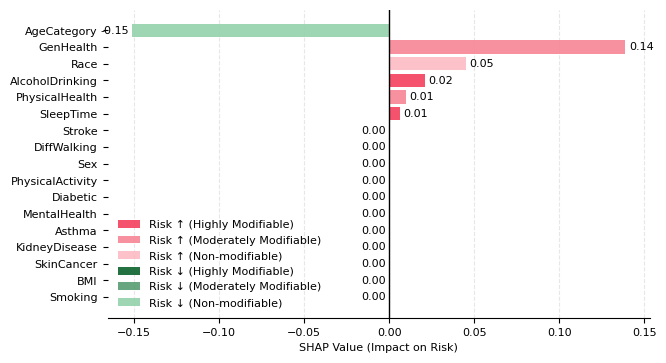

In [37]:
import shap
import matplotlib.pyplot as plt
# make a plot (modifiability not adapted to altered dataset)
background_sample = X_train.sample(n=50, random_state=42)

# user, e.g. 
#user_df = X_test.iloc[[1], :] 

# Call the function
fig, importance_df = compute_shap_plot_voting(
    pipeline, 
    user_df, 
    #user2=modified_user_df,  # optional
    background_data=background_sample
)

In [26]:
X_train.columns

Index(['BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth',
       'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic',
       'PhysicalActivity', 'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease',
       'SkinCancer'],
      dtype='object')

In [25]:
pipeline.predict_proba(user_df)[:,1]  # risk score (0-1)

array([0.40188413])

Stacking Classifier

In [ ]:
# === Stacking classifier (XGB + GB + KNN + RF) + SHAP + threshold tuning ===
# Requirements: scikit-learn, xgboost, imbalanced-learn, shap, matplotlib, seaborn, joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
#import shap
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve
)
from sklearn.inspection import permutation_importance

# ---------------------------
# 0) Data - replace if needed
# ---------------------------
# You said you already have the dataset loaded; I'll assume `heart_df` exists with 'HeartDisease' target.
df = heart_df.copy()                      # <--- ensure heart_df is defined
TARGET = "HeartDisease"                   # adjust if different

X = df.drop(columns=[TARGET])
y = df['HeartDisease']

# train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ---------------------------
# 1) Columns separation
# ---------------------------
num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

# ---------------------------
# 2) Preprocessor
# ---------------------------
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

# ---------------------------
# 3) Best-guess parameters (no GridSearch)
# ---------------------------
# Compute scale_pos_weight for XGBoost (useful if you want to pass it)
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0
print("scale_pos_weight:", round(scale_pos_weight, 3))

# XGBoost params (robust for tabular clinical data)
xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=3,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

# Gradient Boosting (sklearn)
gb_clf = GradientBoostingClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    random_state=42
)

# KNN (sensitive to scaling)
knn_clf = KNeighborsClassifier(n_neighbors=15, weights="distance", p=2)

# Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=42
)

# Stacking final estimator
final_estimator = LogisticRegression(max_iter=2000, class_weight='balanced')

# ---------------------------
# 4) Build stacking classifier inside imbalanced pipeline
# ---------------------------
estimators = [
    ("xgb", xgb_clf),
    ("gb", gb_clf),
    ("knn", knn_clf),
    ("rf", rf_clf)
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    stack_method="predict_proba",  # use predict_proba outputs as meta-features
    n_jobs=-1,
    passthrough=False
)

# Pipeline: preprocess -> SMOTE -> stacking
pipe = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),   # switch to SMOTEENN() if you prefer
    ("model", stacking)
])

# ---------------------------
# 5) Fit the pipeline
# ---------------------------
pipe.fit(X_train, y_train)

# ---------------------------
# 6) Predict probabilities on test
# ---------------------------
probs_test = pipe.predict_proba(X_test)[:, 1]
preds_default = (probs_test >= 0.19).astype(int)

acc = accuracy_score(y_test, preds_default)
prec = precision_score(y_test, preds_default, zero_division=0)
rec = recall_score(y_test, preds_default)
f1 = f1_score(y_test, preds_default)
auc = roc_auc_score(y_test, probs_test)
tn, fp, fn, tp = confusion_matrix(y_test, preds_default).ravel()

print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}")
print(f"TP={tp}, FN={fn}, FP={fp}, TN={tn}")
print("\nCLASSIFICATION REPORT:\n", classification_report(y_test, probs_test))

NameError: name 'heart_df' is not defined